In [2]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.datasets import mnist
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.models import Model


Load Dataset

In [3]:
(x_train,_),(x_test,_) = mnist.load_data()

x_train = x_train.astype('float32')/255.
x_test = x_test.astype('float32')/255.

x_train = x_train.reshape((len(x_train),784))
x_test = x_test.reshape((len(x_test),784))

print(x_train.shape)
print(x_test.shape)


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
(60000, 784)
(10000, 784)


1.Shallow Autoencoder


In [4]:
input_img = Input(shape=(784,))

encoded = Dense(64, activation='relu')(input_img)

decoded = Dense(784, activation='sigmoid')(encoded)

shallow_ae = Model(input_img, decoded)

shallow_ae.compile(optimizer='adam',loss='binary_crossentropy')

shallow_ae.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 784)            │        50,960 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,200 (395.31 KB)

 Trainable params: 101,200 (395.31 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
history = shallow_ae.fit(x_train,x_train,
                         epochs=5,
                         batch_size=256,
                         shuffle=True,
                         validation_data=(x_test,x_test))

Epoch 1/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.0813 - val_loss: 0.0792
Epoch 2/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - loss: 0.0791 - val_loss: 0.0774
Epoch 3/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.0776 - val_loss: 0.0762
Epoch 4/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - loss: 0.0766 - val_loss: 0.0755
Epoch 5/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step - loss: 0.0759 - val_loss: 0.0749


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


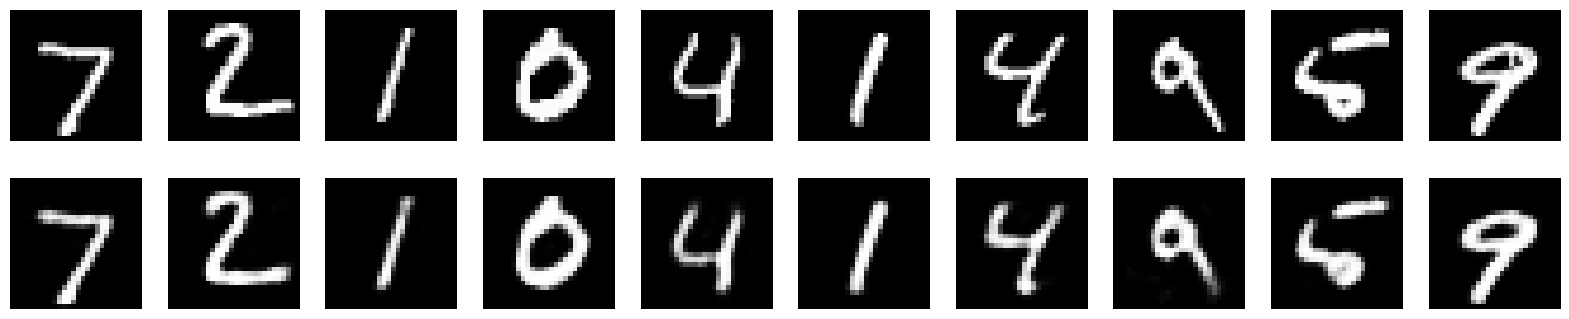

In [7]:
decoded_imgs = shallow_ae.predict(x_test)

n=10

plt.figure(figsize=(20,4))
for i in range(n):
    ax = plt.subplot(2,n,i+1)
    plt.imshow(x_test[i].reshape(28,28),cmap='gray')
    plt.axis('off')

    ax=plt.subplot(2,n,i+1+n)
    plt.imshow(decoded_imgs[i].reshape(28,28),cmap='gray')
    plt.axis('off')

plt.show()

#first column original image and 2nd column is reconstructed image

2. Deep Autoencoders

In [8]:
encoded = Dense(256, activation='relu')(input_img)
encoded = Dense(128, activation='relu')(encoded)
encoded = Dense(64, activation='relu')(encoded)

decoded = Dense(128, activation='relu')(encoded)
decoded = Dense(256, activation='relu')(decoded)
decoded = Dense(784, activation='sigmoid')(decoded)

deep_ae = Model(input_img, decoded)

deep_ae.compile(optimizer='adam',loss='binary_crossentropy')

deep_ae.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 784)            │       201,488 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 484,944 (1.85 MB)

 Trainable params: 484,944 (1.85 MB)

 Non-trainable params: 0 (0.00 B)

In [9]:
deep_ae.fit(x_train,x_train,
            epochs=5,
            batch_size=256,
            shuffle=True,
            validation_data=(x_test,x_test))


Epoch 1/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 10s 35ms/step - loss: 0.2143 - val_loss: 0.1394
Epoch 2/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 25ms/step - loss: 0.1249 - val_loss: 0.1121
Epoch 3/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 10s 26ms/step - loss: 0.1080 - val_loss: 0.1025
Epoch 4/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 7s 32ms/step - loss: 0.1008 - val_loss: 0.0972
Epoch 5/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 25ms/step - loss: 0.0964 - val_loss: 0.0936


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


<function matplotlib.pyplot.show(close=None, block=None)>

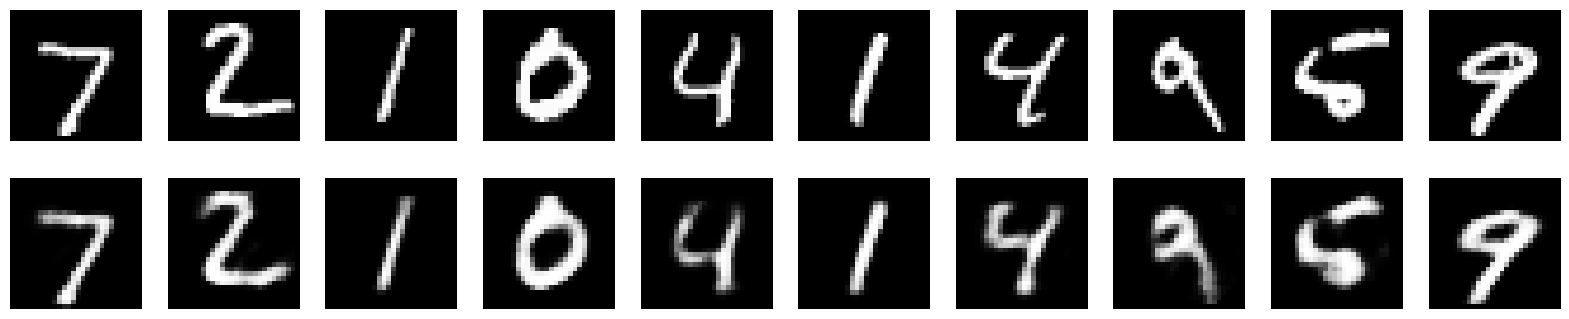

In [10]:
decoded_imgs = deep_ae.predict(x_test)

plt.figure(figsize=(20,4))
for i in range(n):
    ax = plt.subplot(2,n,i+1)
    plt.imshow(x_test[i].reshape(28,28),cmap='gray')
    plt.axis('off')

    ax=plt.subplot(2,n,i+1+n)
    plt.imshow(decoded_imgs[i].reshape(28,28),cmap='gray')
    plt.axis('off')

plt.show


3. Sparse Autoencoder

In [12]:
from tensorflow.keras import regularizers

input_img = Input(shape=(784,))

encoded = Dense(64, activation='relu',
                activity_regularizer=regularizers.l1(10e-4))(input_img)

decoded = Dense(784, activation='sigmoid')(encoded)

sparse_ae = Model(input_img, decoded)

sparse_ae.compile(optimizer='adam',loss='binary_crossentropy')

sparse_ae.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 784)            │        50,960 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,200 (395.31 KB)

 Trainable params: 101,200 (395.31 KB)

 Non-trainable params: 0 (0.00 B)

In [13]:
sparse_ae.fit(x_train,x_train,
            epochs=5,
            batch_size=256,
            shuffle=True,
            validation_data=(x_test,x_test))

Epoch 1/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - loss: 0.6950 - val_loss: 0.6155
Epoch 2/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.5832 - val_loss: 0.5535
Epoch 3/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - loss: 0.5275 - val_loss: 0.5038
Epoch 4/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - loss: 0.4827 - val_loss: 0.4638
Epoch 5/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.4466 - val_loss: 0.4314


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


<function matplotlib.pyplot.show(close=None, block=None)>

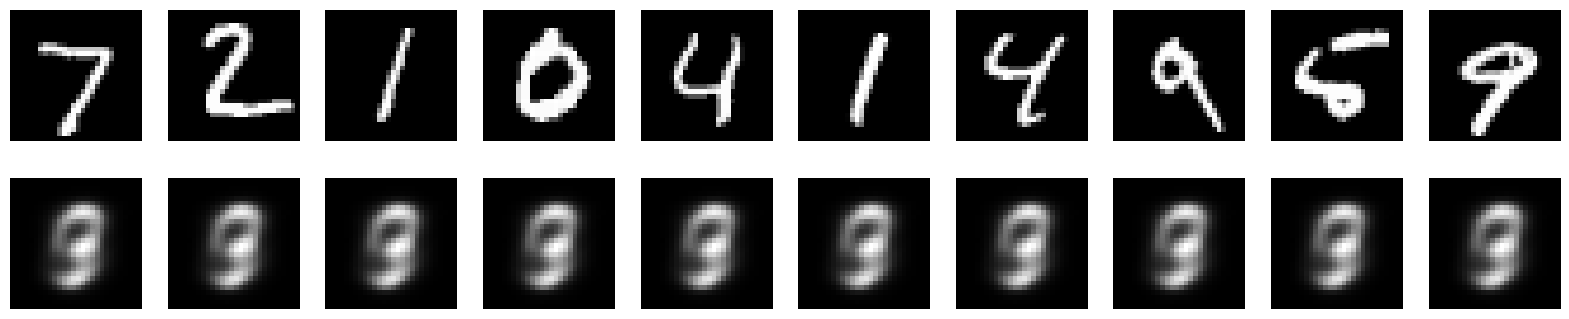

In [16]:
decoded_imgs = sparse_ae.predict(x_test)

plt.figure(figsize=(20,4))
for i in range(n):
    ax = plt.subplot(2,n,i+1)
    plt.imshow(x_test[i].reshape(28,28),cmap='gray')
    plt.axis('off')

    ax=plt.subplot(2,n,i+1+n)
    plt.imshow(decoded_imgs[i].reshape(28,28),cmap='gray')
    plt.axis('off')

plt.show

4. Denoising Autoencoder

In [18]:
noise_factor = 0.5

x_train_noisy = x_train + noise_factor * np.random.normal(loc=0.0,scale=1.0,size=x_train.shape)
x_test_noisy = x_test + noise_factor * np.random.normal(loc=0.0,scale=1.0,size=x_test.shape)

x_train_noisy = np.clip(x_train_noisy,0.,1.)
x_test_noisy = np.clip(x_test_noisy,0.,1.)

In [19]:
input_img = Input(shape=(784,))

encoded = Dense(64, activation='relu')(input_img)
encoded = Dense(32, activation='relu')(encoded)

decoded = Dense(784, activation='relu')(encoded)
decoded = Dense(784, activation='sigmoid')(encoded)

denoising_ae = Model(input_img, decoded)

denoising_ae.compile(optimizer='adam',loss='binary_crossentropy')

In [20]:
denoising_ae.fit(x_train_noisy,x_train,
            epochs=5,
            batch_size=256,
            shuffle=True,
            validation_data=(x_test_noisy,x_test))

Epoch 1/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - loss: 0.2776 - val_loss: 0.2092
Epoch 2/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.1882 - val_loss: 0.1738
Epoch 3/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.1672 - val_loss: 0.1598
Epoch 4/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.1565 - val_loss: 0.1518
Epoch 5/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.1509 - val_loss: 0.1473


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


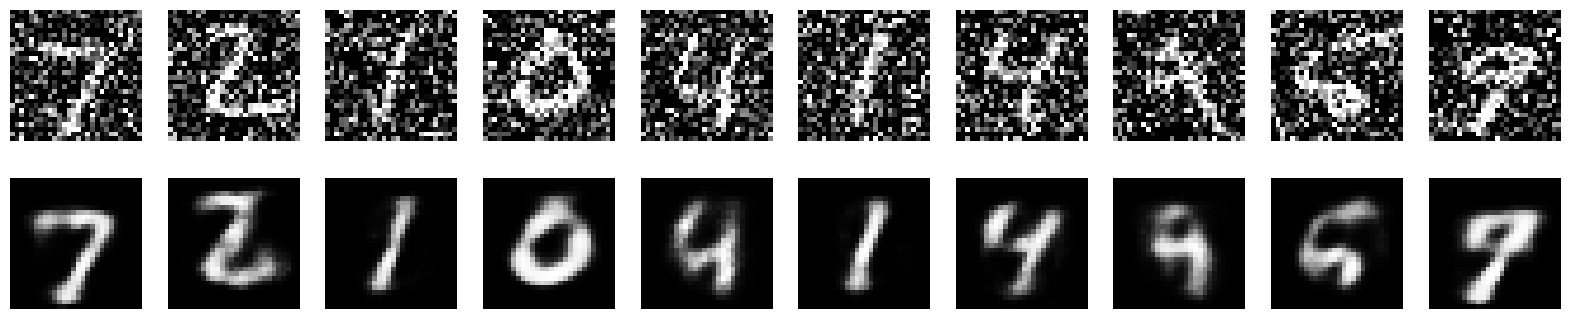

In [22]:
decoded_imgs = denoising_ae.predict(x_test_noisy)

plt.figure(figsize=(20,4))
for i in range(n):
    ax = plt.subplot(2,n,i+1)
    plt.imshow(x_test_noisy[i].reshape(28,28),cmap='gray')
    plt.axis('off')

    ax=plt.subplot(2,n,i+1+n)
    plt.imshow(decoded_imgs[i].reshape(28,28),cmap='gray')
    plt.axis('off')

plt.show()